# INF8225 — Projet : MK-UNet (Équipe 5)
**Salem Christopher — 2144272 | Ezzedine Mahdi — 2146059**  
Chargé de labo : Aziz Attia — Hiver 2026

---
Reproduction de *MK-UNet: Multi-Kernel Lightweight CNN for Medical Image Segmentation*  
Rahman & Marculescu, ICCV 2025 CVAMD — [ArXiv](https://arxiv.org/abs/2509.18493)

### Plan d'action
| Étape | Section |
|-------|---------|
| Set Up | §1 |
| DataLoader | §2 |
| Architecture | §3 |
| Entraînement | §4 |
| Métriques | §5 |
| Visualisations | §6 |
| Analyse | §7 |


---
# 1. Set Up

In [1]:
import os
print(os.getcwd())

c:\Users\mahdi\Desktop\Poly\INF8225-Projet


In [ ]:
# ── Installation (décommenter si nécessaire) ──────────────────────────
# PyTorch AMD / ROCm → voir requirements.txt
# !pip install -r requirements.txt


In [22]:
import os, sys, time, logging
from pathlib import Path
from datetime import datetime

from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch, torch.nn as nn, torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchinfo import summary
import wandb

sys.path.insert(0, os.path.abspath('.'))
from mkunet_network import MKUNet
from utils.dataloader import build_loader
from utils.utils import clip_gradient, RunningAverage, count_params_flops, structure_loss, dice_score, iou_score

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")


Device : cuda
GPU    : NVIDIA GeForce RTX 4070


In [3]:
# ── Configuration globale ─────────────────────────────────────────────
IMG_SIZE    = 352
BATCH_TRAIN = 8
BATCH_EVAL  = 4
EPOCHS      = 100          # papier : 200
LR          = 5e-4
GRAD_CLIP   = 0.5
DATA_ROOT   = Path('./data')
CKPT_DIR    = Path('./checkpoints')
RESULTS_DIR = Path('./results')
CKPT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

WANDB_PROJECT = 'INF8225-MKUNet'

print("Configuration chargée ✓")


Configuration chargée ✓


In [4]:
# ── WandB login ───────────────────────────────────────────────────────
wandb.login()   # décommenter au premier lancement


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\mahdi\_netrc.
wandb: Currently logged in as: mahdi-ezzedine (christopher-salem-polytechnique-montr-al) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

---
# 2. DataLoader

Structure canonique attendue pour chaque dataset :
```
data/<DATASET>/train/images/   train/masks/
               val/images/     val/masks/
               test/images/    test/masks/
```
Les cellules ci-dessous téléchargent et reorganisent chaque dataset
dans cette structure, puis vérifient visuellement quelques paires image/masque.


In [5]:
# ── Helper : affichage d'une grille image / masque ────────────────────
def denorm(t, mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)):
    img = t.clone().cpu().float()
    for c,(m,s) in enumerate(zip(mean,std)):
        img[c] = img[c]*s + m
    return img.permute(1,2,0).numpy().clip(0,1)

def show_samples(loader, n=4, title=''):
    imgs, masks = next(iter(loader))
    fig, axes = plt.subplots(2, n, figsize=(3*n, 6))
    fig.suptitle(title, fontsize=12)
    for i in range(n):
        axes[0,i].imshow(denorm(imgs[i])); axes[0,i].axis('off')
        axes[1,i].imshow(masks[i].squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[1,i].axis('off')
    axes[0,0].set_ylabel('Image'); axes[1,0].set_ylabel('Masque')
    plt.tight_layout(); plt.show()
    print(f"Images : {imgs.shape} | Masques : {masks.shape} | "
          f"Masque min/max : {masks.min()}/{masks.max()}")


## 2.1 BUSI — Breast Ultrasound Images Dataset

BUSI  — train: 517 | val: 65 | test: 65


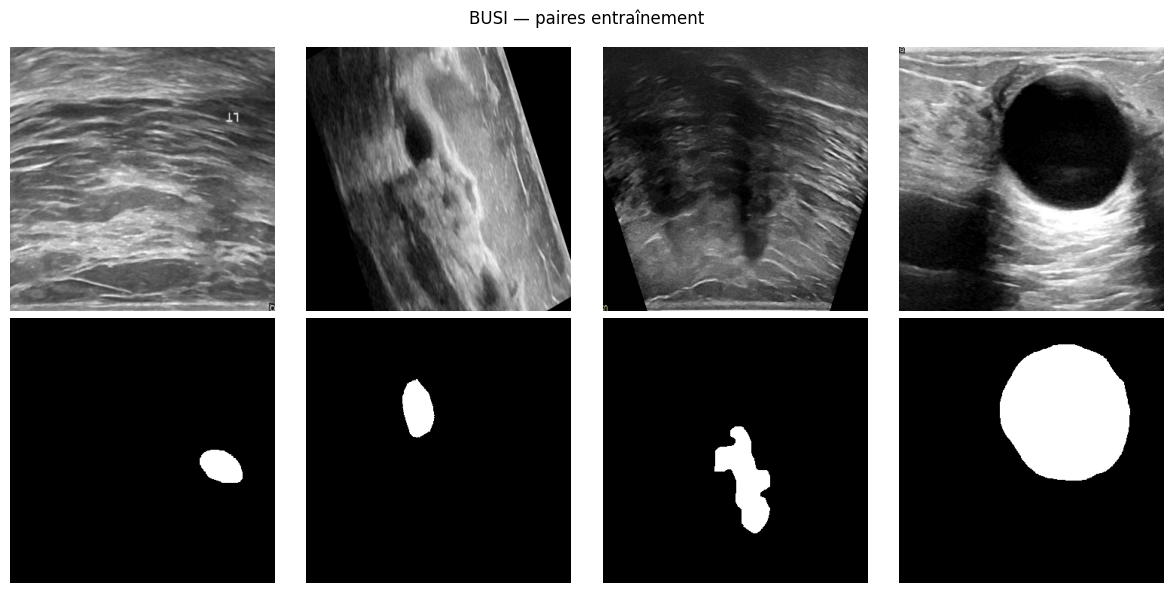

Images : torch.Size([8, 3, 352, 352]) | Masques : torch.Size([8, 1, 352, 352]) | Masque min/max : 0/1


In [6]:
# ── Téléchargement BUSI (Kaggle) ──────────────────────────────────────
# Nécessite un compte Kaggle et le fichier ~/.kaggle/kaggle.json
# !kaggle datasets download -d aryashah2k/breast-ultrasound-images-dataset
# !mkdir -p data/BUSI_raw
# !unzip -q breast-ultrasound-images-dataset.zip -d data/BUSI_raw

# ── Réorganisation BUSI vers structure canonique ──────────────────────
# BUSI contient : Dataset_BUSI_with_GT/{benign,malignant}/{img.png, img_mask.png}
# On fusionne benign + malignant, on ignore 'normal' (pas de lésion).

import shutil, random
from sklearn.model_selection import train_test_split

def organize_busi(raw_dir='data/BUSI_raw/Dataset_BUSI_with_GT',
                  out_dir='data/BUSI', seed=42):
    random.seed(seed)
    pairs = []
    for cls in ('benign', 'malignant'):
        cls_dir = Path(raw_dir) / cls
        if not cls_dir.exists(): continue
        imgs = sorted([p for p in cls_dir.iterdir()
                       if '_mask' not in p.name and p.suffix == '.png'])
        for img_p in imgs:
            mask_p = img_p.with_name(img_p.stem + '_mask.png')
            if mask_p.exists():
                pairs.append((img_p, mask_p))

    tr, tmp = train_test_split(pairs, test_size=0.2, random_state=seed)
    val, te  = train_test_split(tmp,   test_size=0.5, random_state=seed)

    for split, data_pairs in [('train',tr),('val',val),('test',te)]:
        (Path(out_dir)/split/'images').mkdir(parents=True, exist_ok=True)
        (Path(out_dir)/split/'masks').mkdir(parents=True, exist_ok=True)
        for img_p, mask_p in data_pairs:
            shutil.copy(img_p,  Path(out_dir)/split/'images'/img_p.name)
            shutil.copy(mask_p, Path(out_dir)/split/'masks'/mask_p.name)
    print(f"BUSI : train={len(tr)}, val={len(val)}, test={len(te)}")

#organize_busi()   # décommenter une seule fois

# ── Vérification ──────────────────────────────────────────────────────
busi_train = build_loader('data/BUSI/train/images','data/BUSI/train/masks',
                           BATCH_TRAIN, IMG_SIZE, split='train', augment=True)
busi_val   = build_loader('data/BUSI/val/images',  'data/BUSI/val/masks',
                           BATCH_EVAL,  IMG_SIZE, split='test',  augment=False)
busi_test  = build_loader('data/BUSI/test/images', 'data/BUSI/test/masks',
                           BATCH_EVAL,  IMG_SIZE, split='test',  augment=False)
print(f"BUSI  — train: {len(busi_train.dataset)} | val: {len(busi_val.dataset)} | test: {len(busi_test.dataset)}")
show_samples(busi_train, title='BUSI — paires entraînement')


## 2.2 ClinicDB — Polyp Dataset

ClinicDB — train: 489 | val: 61 | test: 62


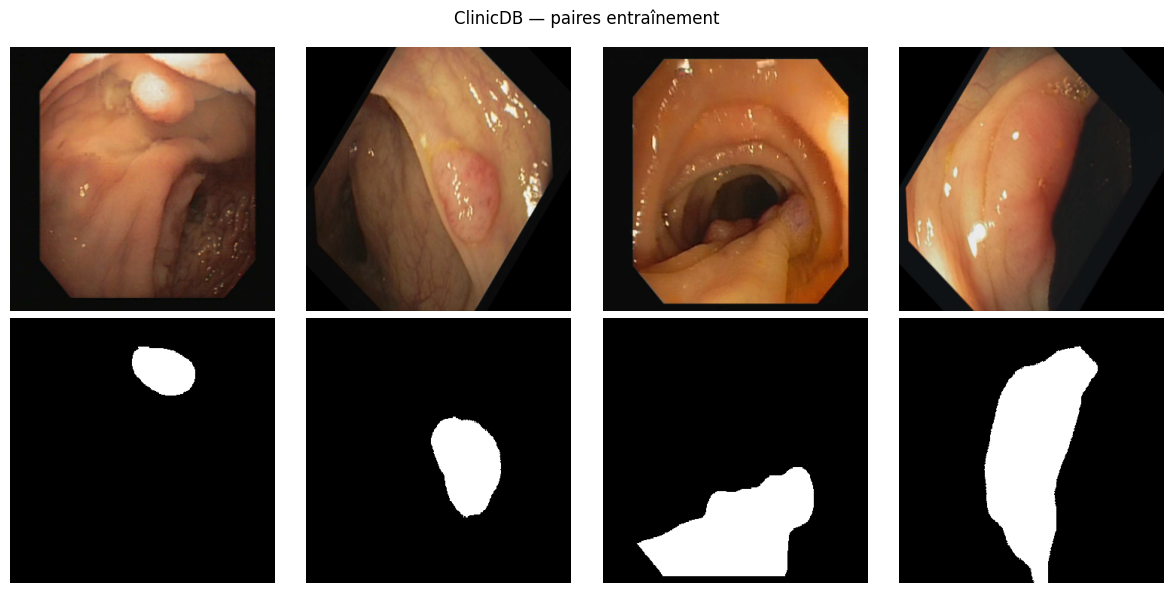

Images : torch.Size([8, 3, 352, 352]) | Masques : torch.Size([8, 1, 352, 352]) | Masque min/max : 0/1


In [7]:
# ── Téléchargement ClinicDB (Google Drive via gdown) ──────────────────
# import gdown
# gdown.download_folder('https://drive.google.com/drive/folders/1FPJr5f91uUCikxMvkwtZSEnYHemTZq1P',
#                        output='data/ClinicDB', quiet=False)

clinicdb_train = build_loader('data/ClinicDB/train/images','data/ClinicDB/train/masks',
                               BATCH_TRAIN, IMG_SIZE, split='train', augment=True)
clinicdb_val   = build_loader('data/ClinicDB/val/images',  'data/ClinicDB/val/masks',
                               BATCH_EVAL,  IMG_SIZE, split='test')
clinicdb_test  = build_loader('data/ClinicDB/test/images', 'data/ClinicDB/test/masks',
                               BATCH_EVAL,  IMG_SIZE, split='test')
print(f"ClinicDB — train: {len(clinicdb_train.dataset)} | val: {len(clinicdb_val.dataset)} | test: {len(clinicdb_test.dataset)}")
show_samples(clinicdb_train, title='ClinicDB — paires entraînement')


## 2.3 ColonDB — Polyp Dataset

ColonDB — train: 303 | val: 38 | test: 38


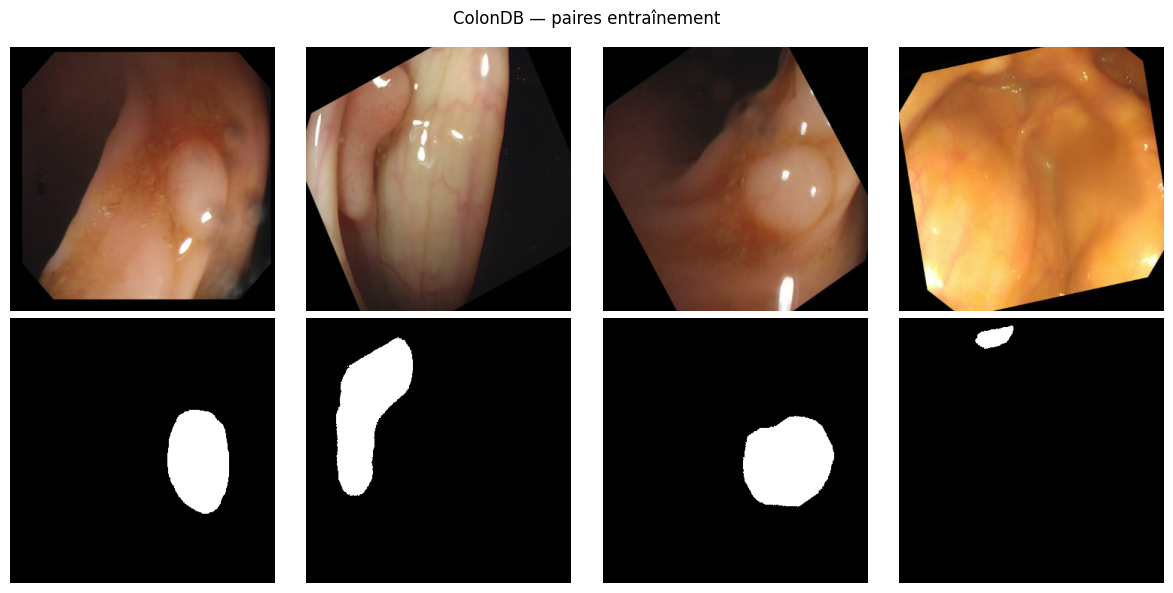

Images : torch.Size([8, 3, 352, 352]) | Masques : torch.Size([8, 1, 352, 352]) | Masque min/max : 0/1


In [8]:
# ── Téléchargement ColonDB ────────────────────────────────────────────
# import gdown
# gdown.download_folder('https://drive.google.com/drive/folders/1u4_8dMztnEBUaX-w3XfUR3jXLBhpccPA',
#                        output='data/ColonDB', quiet=False)

colondb_train = build_loader('data/ColonDB/train/images','data/ColonDB/train/masks',
                              BATCH_TRAIN, IMG_SIZE, split='train', augment=True)
colondb_val   = build_loader('data/ColonDB/val/images',  'data/ColonDB/val/masks',
                              BATCH_EVAL,  IMG_SIZE, split='test')
colondb_test  = build_loader('data/ColonDB/test/images', 'data/ColonDB/test/masks',
                              BATCH_EVAL,  IMG_SIZE, split='test')
print(f"ColonDB — train: {len(colondb_train.dataset)} | val: {len(colondb_val.dataset)} | test: {len(colondb_test.dataset)}")
show_samples(colondb_train, title='ColonDB — paires entraînement')


## 2.4 ISIC18 — Skin Lesion Dataset

In [35]:
#!kaggle datasets download -d bhaveshmittal/melanoma-cancer-dataset
# !unzip -q ISIC2018_Task1_Training_GroundTruth.zip -d data/ISIC18_raw
# !unzip -q ISIC2018_Task1-2_Training_Input.zip -d data/ISIC18_raw

ISIC18 — train: 2075 | val: 259 | test: 260


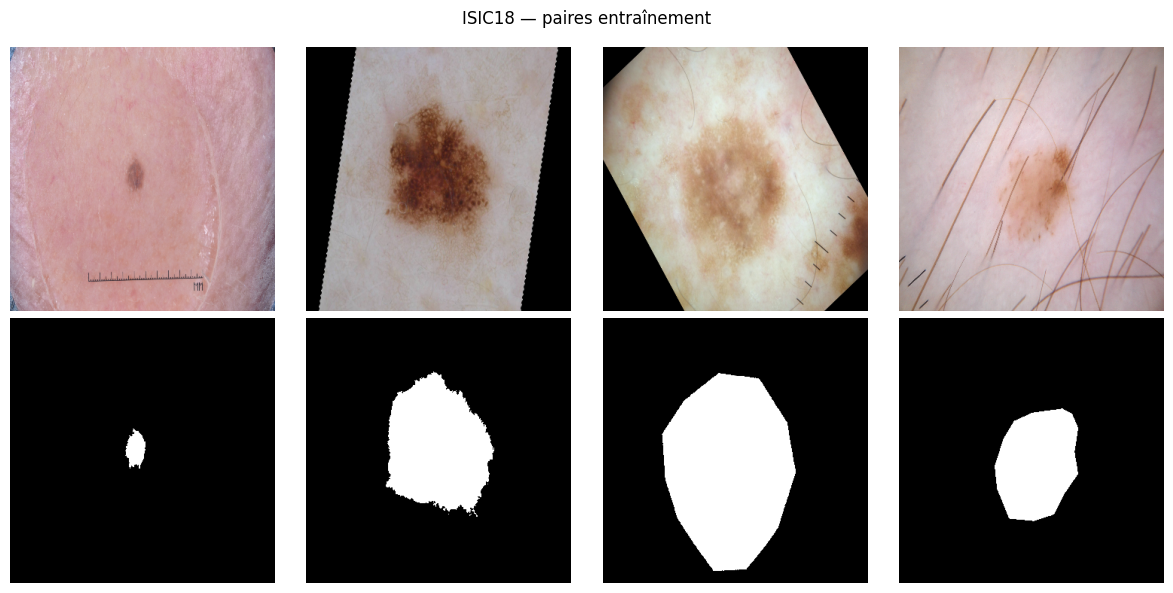

Images : torch.Size([8, 3, 352, 352]) | Masques : torch.Size([8, 1, 352, 352]) | Masque min/max : 0/1


In [9]:
# ── Téléchargement ISIC18 (Kaggle) ───────────────────────────────────
# !kaggle datasets download -d bhaveshmittal/melanoma-cancer-dataset
# !mkdir -p data/ISIC18_raw
# Ou depuis le site officiel ISIC 2018 : https://challenge.isic-archive.com/data/#2018
#
# Réorganisation : les masques ISIC ont le suffixe _segmentation.png
# Les images et masques sont appariés sur le radical du nom de fichier.

def organize_isic18(img_raw='data/ISIC18_raw/ISIC2018_Task1-2_Training_Input',
                    mask_raw='data/ISIC18_raw/ISIC2018_Task1_Training_GroundTruth',
                    out_dir='data/ISIC18', seed=42):
    imgs  = sorted(Path(img_raw).glob('*.jpg'))
    pairs = []
    for img_p in imgs:
        mask_p = Path(mask_raw) / (img_p.stem + '_segmentation.png')
        if mask_p.exists():
            pairs.append((img_p, mask_p))

    tr, tmp = train_test_split(pairs, test_size=0.2, random_state=seed)
    val, te  = train_test_split(tmp,   test_size=0.5, random_state=seed)

    for split, data_pairs in [('train',tr),('val',val),('test',te)]:
        (Path(out_dir)/split/'images').mkdir(parents=True, exist_ok=True)
        (Path(out_dir)/split/'masks').mkdir(parents=True, exist_ok=True)
        for img_p, mask_p in data_pairs:
            shutil.copy(img_p,  Path(out_dir)/split/'images'/img_p.name)
            shutil.copy(mask_p, Path(out_dir)/split/'masks'/(img_p.stem+'_mask.png'))
    print(f"ISIC18 : train={len(tr)}, val={len(val)}, test={len(te)}")

#organize_isic18()  # décommenter une seule fois

isic_train = build_loader('data/ISIC18/train/images','data/ISIC18/train/masks',
                           BATCH_TRAIN, IMG_SIZE, split='train', augment=True)
isic_val   = build_loader('data/ISIC18/val/images',  'data/ISIC18/val/masks',
                           BATCH_EVAL,  IMG_SIZE, split='test')
isic_test  = build_loader('data/ISIC18/test/images', 'data/ISIC18/test/masks',
                           BATCH_EVAL,  IMG_SIZE, split='test')
print(f"ISIC18 — train: {len(isic_train.dataset)} | val: {len(isic_val.dataset)} | test: {len(isic_test.dataset)}")
show_samples(isic_train, title='ISIC18 — paires entraînement')


## 2.5 DSB18 — Data Science Bowl 2018 (Cell Nuclei)

DSB18  — train: 536 | val: 67 | test: 67


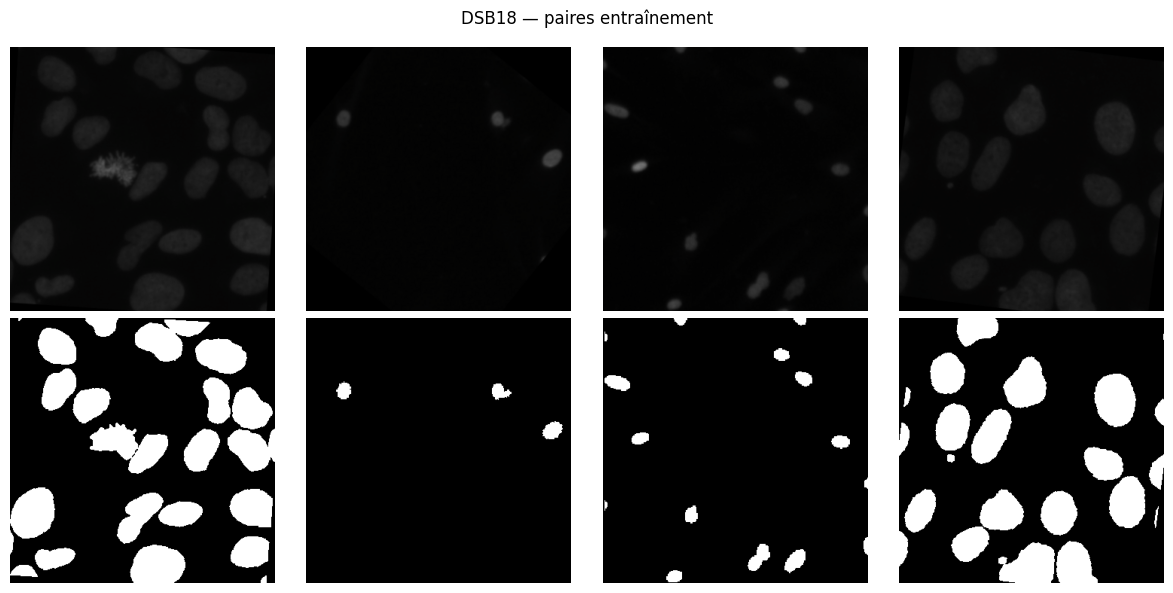

Images : torch.Size([8, 3, 352, 352]) | Masques : torch.Size([8, 1, 352, 352]) | Masque min/max : 0/1


In [10]:
# ── Téléchargement DSB18 ─────────────────────────────────────────────
# !kaggle competitions download -c data-science-bowl-2018
#
# DSB18 : chaque image dans son propre dossier avec sous-dossier masks/
# On fusionne les masques individuels en un seul masque binaire.

def organize_dsb18(raw_dir='data/DSB18_raw/stage1_train',
                   out_dir='data/DSB18', seed=42):
    import cv2
    cases = [d for d in Path(raw_dir).iterdir() if d.is_dir()]
    pairs = []
    for case in cases:
        img_paths = list((case/'images').glob('*.png'))
        if not img_paths: continue
        img_p = img_paths[0]
        # Fusion de tous les masques individuels
        mask_dir = case / 'masks'
        combined = None
        for mp in mask_dir.glob('*.png'):
            m = cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE)
            combined = m if combined is None else np.maximum(combined, m)
        if combined is not None:
            pairs.append((img_p, combined, case.name))

    tr, tmp = train_test_split(pairs, test_size=0.2, random_state=seed)
    val, te  = train_test_split(tmp,   test_size=0.5, random_state=seed)

    for split, data_pairs in [('train',tr),('val',val),('test',te)]:
        (Path(out_dir)/split/'images').mkdir(parents=True, exist_ok=True)
        (Path(out_dir)/split/'masks').mkdir(parents=True, exist_ok=True)
        for img_p, mask_arr, name in data_pairs:
            shutil.copy(img_p, Path(out_dir)/split/'images'/(name+'.png'))
            cv2.imwrite(str(Path(out_dir)/split/'masks'/(name+'.png')), mask_arr)
    print(f"DSB18 : train={len(tr)}, val={len(val)}, test={len(te)}")

#organize_dsb18()   # décommenter une seule fois

dsb_train = build_loader('data/DSB18/train/images','data/DSB18/train/masks',
                          BATCH_TRAIN, IMG_SIZE, split='train', augment=True)
dsb_val   = build_loader('data/DSB18/val/images',  'data/DSB18/val/masks',
                          BATCH_EVAL,  IMG_SIZE, split='test')
dsb_test  = build_loader('data/DSB18/test/images', 'data/DSB18/test/masks',
                          BATCH_EVAL,  IMG_SIZE, split='test')
print(f"DSB18  — train: {len(dsb_train.dataset)} | val: {len(dsb_val.dataset)} | test: {len(dsb_test.dataset)}")
show_samples(dsb_train, title='DSB18 — paires entraînement')


## 2.6 EM — Electron Microscopy (30 images)

EM     — train: 18 | val: 6 | test: 6


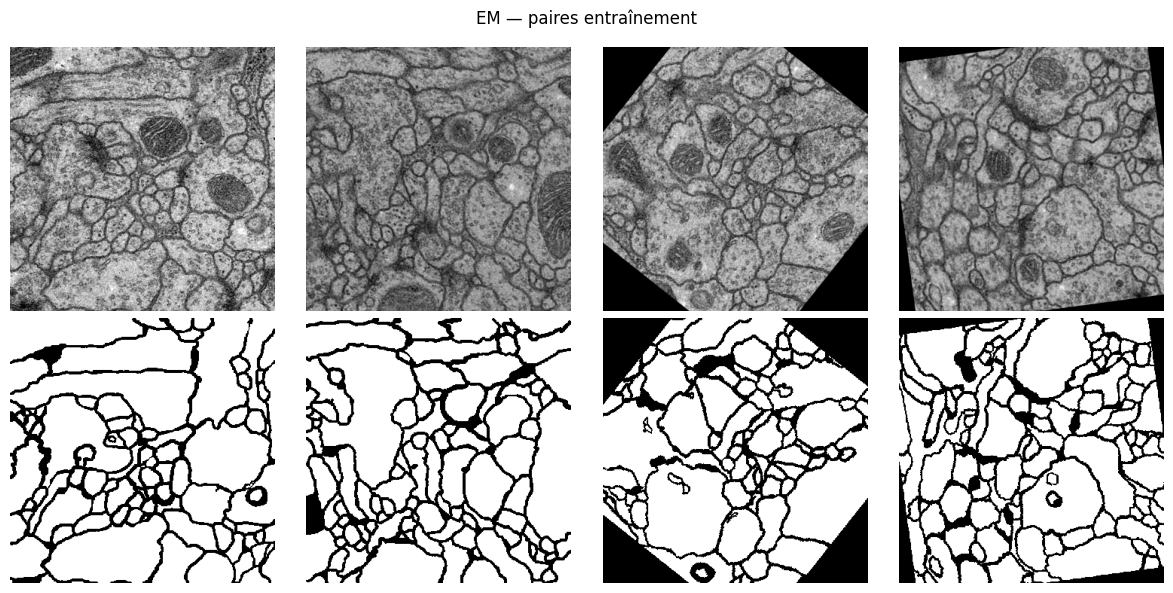

Images : torch.Size([4, 3, 352, 352]) | Masques : torch.Size([4, 1, 352, 352]) | Masque min/max : 0/1


In [11]:
# ── EM : très petit dataset (30 images) ──────────────────────────────
# Source : ISBI 2012 Segmentation Challenge
# https://forum.image.sc/t/isbi-2012-site-down/57867
# Télécharger train-volume.tif et train-labels.tif
# On découpe les stacks tif en images individuelles.

def organize_em(vol_path='data/EM_raw/train-volume.tif',
                lbl_path='data/EM_raw/train-labels.tif',
                out_dir='data/EM', seed=42):
    from PIL import Image as PILImage
    vol = PILImage.open(vol_path)
    lbl = PILImage.open(lbl_path)
    n_frames = vol.n_frames
    pairs = list(range(n_frames))

    tr, tmp = train_test_split(pairs, test_size=0.4, random_state=seed)
    val, te  = train_test_split(tmp,   test_size=0.5, random_state=seed)

    for split, idxs in [('train',tr),('val',val),('test',te)]:
        (Path(out_dir)/split/'images').mkdir(parents=True, exist_ok=True)
        (Path(out_dir)/split/'masks').mkdir(parents=True, exist_ok=True)
        for idx in idxs:
            vol.seek(idx); vol.save(Path(out_dir)/split/'images'/f'em_{idx:03d}.png')
            lbl.seek(idx); lbl.save(Path(out_dir)/split/'masks' /f'em_{idx:03d}.png')
    print(f"EM : train={len(tr)}, val={len(val)}, test={len(te)}")

#organize_em()   # décommenter une seule fois

# EM est en grayscale → rgb=False
em_train = build_loader('data/EM/train/images','data/EM/train/masks',
                         min(4, BATCH_TRAIN), IMG_SIZE, split='train', augment=True, rgb=True)
em_val   = build_loader('data/EM/val/images',  'data/EM/val/masks',
                         2, IMG_SIZE, split='test', rgb=False)
em_test  = build_loader('data/EM/test/images', 'data/EM/test/masks',
                         2, IMG_SIZE, split='test', rgb=False)
print(f"EM     — train: {len(em_train.dataset)} | val: {len(em_val.dataset)} | test: {len(em_test.dataset)}")
show_samples(em_train, title='EM — paires entraînement')


---
# 3. Architecture — MKUNet

## Blocs principaux

**MKDC** (*Multi-Kernel Depthwise Convolution*) : P convolutions dépthwise en parallèle avec des noyaux différents (1×1, 3×3, 5×5). Chaque branche applique DWConv → BN → ReLU6. Les sorties sont sommées.

**MKIR** (*Multi-Kernel Inverted Residual*) : bloc MobileNetV2 où la DWConv standard est remplacée par MKDC. Schéma : PW-expand → MKDC → somme → PW-project + skip connection.

**CA** (*Channel Attention*) + **SA** (*Spatial Attention*) : modules CBAM appliqués séquentiellement avant chaque étage décodeur → **MKIRA** = CA → SA → MKIR.

**GAG** (*Grouped Attention Gate*) : modulation des skip connections. Calcule ψ = σ(W_ψ·ReLU(W_g·g + W_x·x)) et renvoie x·ψ pour supprimer les features encodeur non pertinentes.


In [12]:
# ── Instanciation du modèle (variante de base : ~0.8 M params) ────────
model = MKUNet(
    num_classes      = 1,
    in_channels      = 3,
    channels         = [16, 32, 64, 96, 160],
    blocks_per_stage = [1, 1, 1, 1, 1],
    kernel_sizes     = [1, 3, 5],
    expansion_ratio  = 2,
    gag_kernel       = 3,
).to(DEVICE)

summary(model, input_size=(1, 3, IMG_SIZE, IMG_SIZE),
        col_names=['output_size','num_params','trainable'], depth=3)


Layer (type:depth-idx)                             Output Shape              Param #                   Trainable
MKUNet                                             [1, 1, 352, 352]          --                        True
├─Sequential: 1-1                                  [1, 16, 352, 352]         --                        True
│    └─MKIR: 2-1                                   [1, 16, 352, 352]         --                        True
│    │    └─Sequential: 3-1                        [1, 6, 352, 352]          30                        True
│    │    └─MKDC: 3-2                              [1, 6, 352, 352]          246                       True
│    │    └─Sequential: 3-3                        [1, 16, 352, 352]         128                       True
│    │    └─Conv2d: 3-4                            [1, 16, 352, 352]         48                        True
├─Sequential: 1-2                                  [1, 32, 176, 176]         --                        True
│    └─MKIR: 2-2       

In [13]:
# ── FLOPs & Paramètres ────────────────────────────────────────────────
flops_G, params_M = count_params_flops(model, IMG_SIZE)
print(f"FLOPs : {flops_G:.3f} G  |  Paramètres : {params_M:.3f} M")


FLOPs : 0.619 G  |  Paramètres : 0.316 M


---
# 4. Entraînement

## Fonction de perte : Structure Loss

Combinaison BCE + IoU avec pondération bord-de-masque (PraNet) :
$$w = 1 + 5|\text{AvgPool}(y) - y|$$
$$\mathcal{L} = w \cdot \text{BCE}(\hat{p}, y) + \left(1 - \frac{\sum \hat{p} \cdot y \cdot w + 1}{\sum (\hat{p}+y) \cdot w - \sum \hat{p} \cdot y \cdot w + 1}\right)$$

## Protocole
- Optimiseur : AdamW, lr = 5e-4, weight_decay = 1e-4
- Scheduler  : CosineAnnealingLR (T_max = EPOCHS, η_min = 1e-6)
- Multi-scale training : redimensionnement aléatoire ×0.75 / ×1 / ×1.25
- Sauvegarde du meilleur checkpoint (val Dice)


In [18]:
# ── Fonctions d'évaluation et d'entraînement ──────────────────────────

def print_logs(dataset_type: str, logs: dict):
    """Affiche les métriques de manière lisible.

    Args
    ----
        dataset_type : "Train", "Val" ou "Test".
        logs         : Dictionnaire {nom_métrique: valeur}.
    """
    desc = [f'{name}: {value:.4f}' for name, value in logs.items()]
    desc = '\t'.join(desc)
    desc = f'{dataset_type} -\t' + desc
    desc = desc.expandtabs(5)
    print(desc)


@torch.no_grad()
def evaluate(model, loader, return_sample=False):
    """Calcule mDice, mIoU et val_loss sur un loader val/test.
    Si return_sample=True, retourne aussi un triplet (image, gt, pred) pour WandB.
    """
    model.eval()
    logs = defaultdict(list)
    sample = None

    for batch_idx, (imgs, masks, orig_sizes, _) in enumerate(loader):
        imgs  = imgs.to(DEVICE)
        masks = masks.float().to(DEVICE)
        preds = model(imgs)[0]

        # ── Validation loss (à la résolution d'entraînement) ──────────
        loss = structure_loss(preds, masks)
        logs['loss'].append(loss.item())

        # ── Capture d'un sample qualitatif (premier batch, premier item) ──
        if return_sample and batch_idx == 0 and sample is None:
            p_vis = torch.sigmoid(preds[0:1]).cpu()
            p_vis = (p_vis >= 0.5).float()
            sample = (imgs[0].cpu(), masks[0].cpu(), p_vis.squeeze(0))

        for i in range(len(imgs)):
            orig_h, orig_w = int(orig_sizes[0][i]), int(orig_sizes[1][i])
            p = F.interpolate(preds[i:i+1], size=(orig_h, orig_w),
                              mode='bilinear', align_corners=False)
            p = torch.sigmoid(p).squeeze()
            p = (p - p.min()) / (p.max() - p.min() + 1e-8)

            g = F.interpolate(masks[i:i+1], size=(orig_h, orig_w),
                              mode='nearest').squeeze()
            pb = (p >= 0.5).float(); gb = (g >= 0.2).float()
            logs['dice'].append(dice_score(pb, gb))
            logs['iou'].append(iou_score(pb, gb))

    for name, values in logs.items():
        logs[name] = float(np.mean(values))

    if return_sample:
        return dict(logs), sample
    return dict(logs)


def make_wandb_seg_panel(img_t, gt_t, pred_t):
    """Compose une figure matplotlib (Image | GT | Prédiction) et la renvoie
    sous forme de wandb.Image pour être loggée dans le dashboard.
    Args
    ----
        img_t  : tensor (3,H,W) normalisé ImageNet — l'image d'entrée.
        gt_t   : tensor (1,H,W) ou (H,W) — masque ground-truth.
        pred_t : tensor (1,H,W) ou (H,W) — masque prédit binarisé.
    """
    def denorm(t, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
        img = t.clone().float()
        for c in range(img.shape[0]):
            img[c] = img[c] * std[c] + mean[c]
        return img.permute(1, 2, 0).numpy().clip(0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    axes[0].imshow(denorm(img_t));                          axes[0].set_title('Image');      axes[0].axis('off')
    axes[1].imshow(gt_t.squeeze().numpy(),   cmap='gray');  axes[1].set_title('Masque GT');  axes[1].axis('off')
    axes[2].imshow(pred_t.squeeze().numpy(), cmap='gray');  axes[2].set_title('Prédiction'); axes[2].axis('off')
    fig.tight_layout(pad=0.5)
    wandb_img = wandb.Image(fig, caption='val sample')
    plt.close(fig)
    return wandb_img


def train_one_epoch(model, loader, optimizer, size_rates=(0.75, 1.0, 1.25)):
    model.train()
    logs = defaultdict(list)

    for imgs, masks in loader:
        for rate in size_rates:
            optimizer.zero_grad()
            x = imgs.to(DEVICE); y = masks.float().to(DEVICE)
            if rate != 1.0:
                ts = int(round(IMG_SIZE * rate / 32) * 32)
                x = F.interpolate(x, (ts, ts), mode='bilinear', align_corners=True)
                y = F.interpolate(y, (ts, ts), mode='nearest')
            loss = structure_loss(model(x)[0], y)
            loss.backward()
            clip_gradient(optimizer, GRAD_CLIP)
            optimizer.step()
            if rate == 1.0:
                logs['loss'].append(loss.item())

    for name, values in logs.items():
        logs[name] = float(np.mean(values))
    return dict(logs)

## 4.1 Choix du dataset d'entraînement

Modifie `ACTIVE_DATASET` pour changer de dataset.

In [17]:
# ── Choix du dataset actif ────────────────────────────────────────────
# Options : 'BUSI' | 'ClinicDB' | 'ColonDB' | 'ISIC18' | 'DSB18' | 'EM'
ACTIVE_DATASET = 'EM'

loaders = {
    'BUSI'    : (busi_train,     busi_val,     busi_test),
    'ClinicDB': (clinicdb_train, clinicdb_val, clinicdb_test),
    'ColonDB' : (colondb_train,  colondb_val,  colondb_test),
    'ISIC18'  : (isic_train,     isic_val,     isic_test),
    'DSB18'   : (dsb_train,      dsb_val,      dsb_test),
    'EM'      : (em_train,       em_val,       em_test),
}
train_loader, val_loader, test_loader = loaders[ACTIVE_DATASET]
print(f"Dataset actif : {ACTIVE_DATASET}")
print(f"  train={len(train_loader.dataset)} | val={len(val_loader.dataset)} | test={len(test_loader.dataset)}")


Dataset actif : EM
  train=18 | val=6 | test=6


In [19]:
# ── Initialisation run ────────────────────────────────────────────────
model = MKUNet(    
    num_classes      = 1,
    in_channels      = 3,
    channels         = [16, 32, 64, 96, 160],
    blocks_per_stage = [1, 1, 1, 1, 1],
    kernel_sizes     = [1, 3, 5],
    expansion_ratio  = 2,
    gag_kernel       = 3,).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

RUN_ID   = f"{ACTIVE_DATASET}_MKUNet_{datetime.now().strftime('%m%d_%H%M')}"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

wandb.init(
    project=WANDB_PROJECT,
    name=RUN_ID,
    config={
        'dataset'    : ACTIVE_DATASET, 'epochs': EPOCHS,
        'batch_size' : BATCH_TRAIN,    'lr': LR,
        'img_size'   : IMG_SIZE,       'channels': [16, 32, 64, 96, 160],
        'kernel_sizes': [1, 3, 5],     'loss': 'structure_loss',
        'flops_G'    : flops_G,        'params_M': params_M,
    }
)

# ── Définit epoch comme axe X de référence pour tous les logs ──────────
# Sans cette ligne WandB utilise son propre compteur interne (_step)
# comme axe X par défaut, ce qui peut désynchroniser les courbes.
wandb.define_metric("epoch")
wandb.define_metric("train/*", step_metric="epoch")
wandb.define_metric("val/*",   step_metric="epoch")
wandb.define_metric("lr",      step_metric="epoch")

print(f"Run : {RUN_ID}")


KeyboardInterrupt: 

In [63]:
# ── Boucle d'entraînement ─────────────────────────────────────────────
from collections import defaultdict
import time
import torch
import wandb
import matplotlib.pyplot as plt

VIS_EVERY = 5   # log un sample visuel toutes les N epochs
history = defaultdict(list)
best_dice, best_epoch = 0.0, 0

print(f'Starting training for {EPOCHS} epochs, using {DEVICE}.')

for epoch in range(1, EPOCHS + 1):
    print(f'\nEpoch {epoch}')
    t0 = time.time()

    # ── Train ─────────────────────────────────────────────────────────
    train_logs = train_one_epoch(model, train_loader, optimizer)
    print_logs('Train', train_logs)

    # ── Validation ────────────────────────────────────────────────────
    want_sample = (epoch % VIS_EVERY == 0) or (epoch == 1)
    if want_sample:
        val_logs, sample = evaluate(model, val_loader, return_sample=True)
    else:
        val_logs = evaluate(model, val_loader)
        sample   = None
    print_logs('Val', val_logs)

    scheduler.step()
    lr_now = optimizer.param_groups[0]['lr']

    for name, value in train_logs.items():
        history[f'train_{name}'].append(value)
    for name, value in val_logs.items():
        history[f'val_{name}'].append(value)

    # ── Logs WandB ────────────────────────────────────────────────────
    wandb_dict = {'epoch': epoch, 'lr': lr_now}
    wandb_dict.update({f'train/{k}': v for k, v in train_logs.items()})
    wandb_dict.update({f'val/{k}':   v for k, v in val_logs.items()})

    if sample is not None:
        img_t, gt_t, pred_t = sample
        wandb_dict['val/segmentation_sample'] = make_wandb_seg_panel(img_t, gt_t, pred_t)

    wandb.log(wandb_dict)

    # ── Checkpoint ────────────────────────────────────────────────────
    val_dice = val_logs['dice']
    if val_dice > best_dice:
        best_dice, best_epoch = val_dice, epoch
        torch.save(model.state_dict(), CKPT_DIR / f'{RUN_ID}_best.pth')
        wandb.run.summary['best_val_dice'] = best_dice
        wandb.run.summary['best_epoch']    = best_epoch
        print(f'  ★ New best checkpoint (dice={best_dice:.4f})')

    print(f'  Time: {time.time()-t0:.0f}s  |  lr={lr_now:.2e}')

print(f'\nMeilleur val Dice : {best_dice:.4f} (epoch {best_epoch})')
wandb.finish()

Starting training for 100 epochs, using cuda.

Epoch 1
Train -   loss: 1.4016
Val -     loss: 1.2969   dice: 0.8401   iou: 0.7280
  ★ New best checkpoint (dice=0.8401)
  Time: 2s  |  lr=5.00e-04

Epoch 2
Train -   loss: 1.2824
Val -     loss: 1.2846   dice: 0.5020   iou: 0.3825
  Time: 2s  |  lr=5.00e-04

Epoch 3
Train -   loss: 1.2263
Val -     loss: 1.2534   dice: 0.2208   iou: 0.1697
  Time: 2s  |  lr=4.99e-04

Epoch 4
Train -   loss: 1.1884
Val -     loss: 1.2205   dice: 0.2108   iou: 0.1474
  Time: 2s  |  lr=4.98e-04

Epoch 5
Train -   loss: 1.1565
Val -     loss: 1.1969   dice: 0.3641   iou: 0.2483
  Time: 3s  |  lr=4.97e-04

Epoch 6
Train -   loss: 1.1252
Val -     loss: 1.1712   dice: 0.3120   iou: 0.1950
  Time: 2s  |  lr=4.96e-04

Epoch 7
Train -   loss: 1.0941
Val -     loss: 1.1569   dice: 0.3008   iou: 0.1893
  Time: 2s  |  lr=4.94e-04

Epoch 8
Train -   loss: 1.0606
Val -     loss: 1.1517   dice: 0.2397   iou: 0.1433
  Time: 2s  |  lr=4.92e-04

Epoch 9
Train -   loss: 1.0

epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇█
lr,███████▇▇▇▇▇▇▇▆▆▅▅▅▅▅▄▄▄▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁
train/loss,██▆▆▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/dice,█▂▃▃▂▇▄▁▁▄▇▇▇▆▆▇▆▆▆▆▆▆▆▆▆▆▆▆▆▅▅▅▅▅▅▅▅▅▅▅
val/iou,█▅▂▃▃▄▁▂▂▆▆▅▅▆▆▅▅▅▄▅▅▅▅▅▄▄▄▄▅▅▅▄▄▅▅▅▅▅▅▅
val/loss,▂▁▁▂▃▆▆▇▅▅▅▅▅▄▅▆▆▇▇▅▆▇▅▆▆█████▇▇▇▇▇▇▇▇▇▇
best_epoch,1
best_val_dice,0.84006
epoch,100
lr,0.0
train/loss,0.48678


---
# 5. Métriques — Évaluation par dataset

Chaque cellule charge le meilleur checkpoint entraîné sur ce dataset
et évalue mDice + mIoU sur le split test.


In [15]:
def eval_dataset(ckpt_path, test_loader, dataset_name):
    m = MKUNet(num_classes=1, in_channels=3).to(DEVICE)
    m.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    
    # Récupère le dictionnaire de logs
    results = evaluate(m, test_loader) 
    
    # Extrait les valeurs du dictionnaire
    dice = results['dice']
    iou = results['iou']
    
    print(f"  {dataset_name:<10}  mDice = {dice:.4f}   mIoU = {iou:.4f}")
    return {'dataset': dataset_name, 'mDice': round(dice, 4), 'mIoU': round(iou, 4)}


## 5.1 BUSI

In [23]:
# Remplace le chemin par le checkpoint entraîné sur BUSI
busi_res = eval_dataset('checkpoints/BUSI_MKUNet_0423_2104_best.pth', busi_test, 'BUSI')


C:\Users\mahdi\AppData\Local\Temp\ipykernel_9668\1347518662.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  m.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))

  BUSI        mDice = 0.6629   mIoU = 0.5592


## 5.2 ClinicDB

In [24]:
clinicdb_res = eval_dataset('checkpoints/ClinicDB_MKUNet_0423_1831_best.pth', clinicdb_test, 'ClinicDB')


C:\Users\mahdi\AppData\Local\Temp\ipykernel_9668\1347518662.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  m.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))

  ClinicDB    mDice = 0.8897   mIoU = 0.8164


## 5.3 ColonDB

In [25]:
colondb_res = eval_dataset('checkpoints/ColonDB_MKUNet_0423_2006_best.pth', colondb_test, 'ColonDB')


C:\Users\mahdi\AppData\Local\Temp\ipykernel_9668\1347518662.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  m.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))

  ColonDB     mDice = 0.8418   mIoU = 0.7576


## 5.4 ISIC18

In [26]:
isic_res = eval_dataset('checkpoints/ISIC18_MKUNet_0423_1907_best.pth', isic_test, 'ISIC18')


C:\Users\mahdi\AppData\Local\Temp\ipykernel_9668\1347518662.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  m.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))

  ISIC18      mDice = 0.8871   mIoU = 0.8171


## 5.5 DSB18

In [27]:
dsb_res = eval_dataset('checkpoints/DSB18_MKUNet_0423_2213_best.pth', dsb_test, 'DSB18')


C:\Users\mahdi\AppData\Local\Temp\ipykernel_9668\1347518662.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  m.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))

  DSB18       mDice = 0.8872   mIoU = 0.8044


## 5.6 EM

In [28]:
em_res = eval_dataset('checkpoints/EM_MKUNet_0423_2250_best.pth', em_test, 'EM')


C:\Users\mahdi\AppData\Local\Temp\ipykernel_9668\1347518662.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  m.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))

  EM          mDice = 0.8298   mIoU = 0.7114


## 5.7 Tableau récapitulatif

In [29]:
# ── Tableau comparatif ────────────────────────────────────────────────
all_res = [busi_res, clinicdb_res, colondb_res, isic_res, dsb_res, em_res]
df = pd.DataFrame(all_res)
print("\n" + "="*42)
print("  RÉSULTATS — MKUNet (base, ~0.8M params)")
print("="*42)
print(df.to_string(index=False))
print("="*42)
df.to_excel(RESULTS_DIR / 'summary_all_datasets.xlsx', index=False)
print(f"Tableau sauvegardé → {RESULTS_DIR}/summary_all_datasets.xlsx")



  RÉSULTATS — MKUNet (base, ~0.8M params)
 dataset  mDice   mIoU
    BUSI 0.6629 0.5592
ClinicDB 0.8897 0.8164
 ColonDB 0.8418 0.7576
  ISIC18 0.8871 0.8171
   DSB18 0.8872 0.8044
      EM 0.8298 0.7114
Tableau sauvegardé → results/summary_all_datasets.xlsx


---
# 6. Visualisations

## 6.1 Courbes d'entraînement

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Courbes — {RUN_ID}', fontsize=12)
ep = range(1, len(history['train_loss'])+1)

axes[0].plot(ep, history['train_loss'], color='steelblue')
axes[0].set(title='Train Loss', xlabel='Epoch', ylabel='Loss')
axes[0].axvline(best_epoch, color='r', ls='--', alpha=.7, label=f'Best (ep {best_epoch})')
axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].plot(ep, history['val_dice'], color='darkorange')
axes[1].set(title='Val mDice', xlabel='Epoch', ylabel='Dice')
axes[1].axhline(best_dice, color='g', ls=':', alpha=.7, label=f'Best={best_dice:.4f}')
axes[1].legend(); axes[1].grid(alpha=.3)

axes[2].plot(ep, history['val_iou'], color='mediumseagreen')
axes[2].set(title='Val mIoU', xlabel='Epoch', ylabel='IoU')
axes[2].grid(alpha=.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / f'curves_{RUN_ID}.png', dpi=150, bbox_inches='tight')
plt.show()


## 6.2 Prédictions qualitatives côte à côte

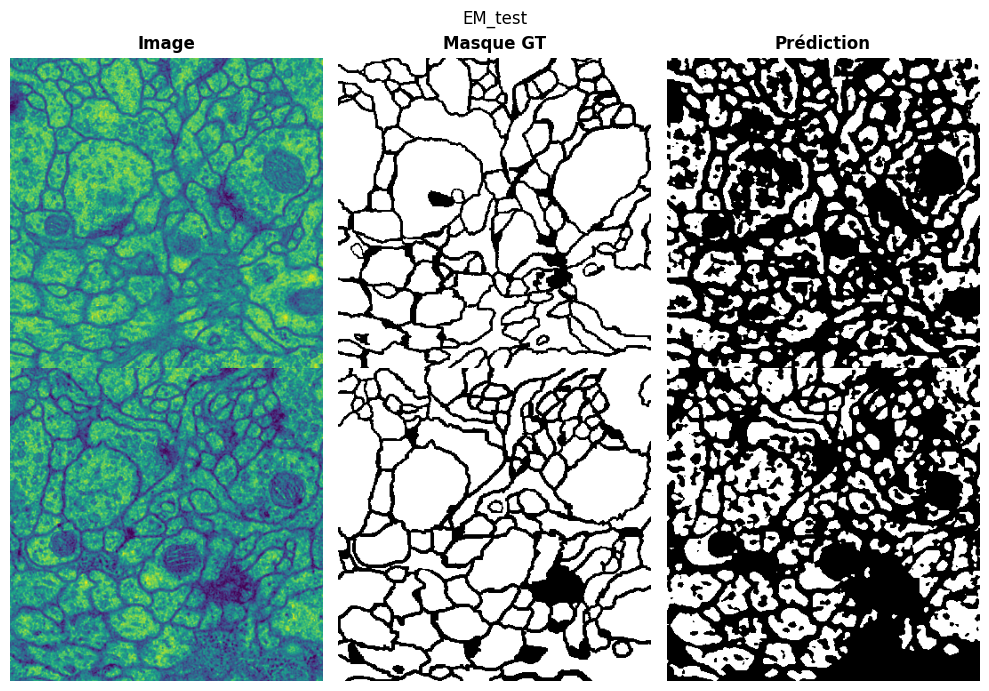

In [67]:
def denorm(t, mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)):
    img = t.clone().cpu().float()
    for c in range(img.shape[0]):
        img[c] = img[c] * std[c] + mean[c]
    return img.permute(1,2,0).numpy().clip(0,1)

def qualitative_grid(model, loader, n=6, title=''):
    model.eval()
    imgs, masks, _, _ = next(iter(loader))
    with torch.no_grad():
        preds = torch.sigmoid(model(imgs.to(DEVICE))[0]).cpu()
    n = min(n, len(imgs))
    fig, axes = plt.subplots(n, 3, figsize=(10, 3.5*n))
    fig.suptitle(title, fontsize=12)
    for col, lbl in enumerate(['Image','Masque GT','Prédiction']):
        axes[0,col].set_title(lbl, fontweight='bold')

    for i in range(n):
        p_bin = (preds[i].squeeze() >= 0.5).float()
        g_bin = (masks[i].squeeze() >= 0.2).float()
        dice  = dice_score(p_bin, g_bin)
        axes[i,0].imshow(denorm(imgs[i]))
        axes[i,1].imshow(g_bin,   cmap='gray', vmin=0, vmax=1)
        axes[i,2].imshow(p_bin,   cmap='gray', vmin=0, vmax=1)
        axes[i,0].set_ylabel(f'Dice={dice:.3f}', fontsize=9)
        for j in range(3): axes[i,j].axis('off')

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'qualitative_{title}.png', dpi=130, bbox_inches='tight')
    plt.show()

# Exemples pour le dataset actif
qualitative_grid(model, test_loader, n=6, title=f'{ACTIVE_DATASET}_test')

## 6.3 Bar chart comparatif multi-dataset

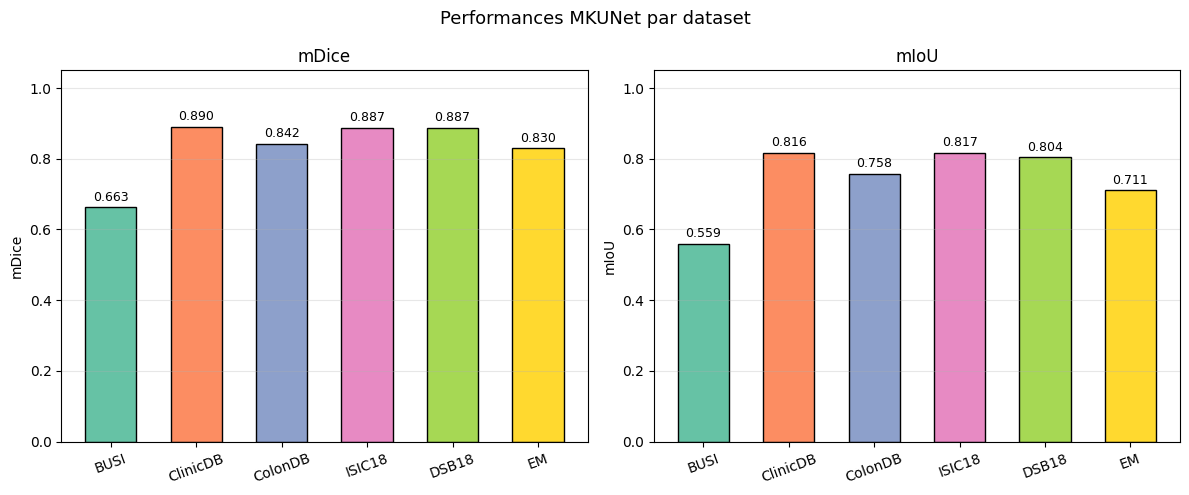

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Performances MKUNet par dataset', fontsize=13)
colors = plt.cm.Set2.colors

for ax, metric in zip(axes, ['mDice', 'mIoU']):
    vals = [r[metric] for r in all_res]
    names = [r['dataset'] for r in all_res]
    bars = ax.bar(names, vals, color=colors[:len(vals)], edgecolor='k', width=0.6)
    ax.set(title=metric, ylabel=metric, ylim=(0, 1.05))
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'comparison_all_datasets.png', dpi=150, bbox_inches='tight')
plt.show()
